# Notebook 02: Text Cleaning, Boilerplate Removal & Feature Engineering

## 1. Introduction and Objectives

This notebook represents the second step in our data processing pipeline for analyzing Steam reviews. The main objective is to prepare the raw text from the ingestion phase to feed our future sentiment classification and topic modeling models.

### Scope of this notebook:
* Handling missing textual data (`isna` values).
* Removing platform-specific boilerplate text (e.g., `"Product received for free."`).
* Standardizing text through lowercasing and whitespace normalization.
* Performing text deduplication to mitigate noise, spam, and review-bombing campaigns.
* Engineering key features and target variables for downstream modeling tasks.

---

### Overall Project Pipeline:
1. **Notebook 01:** Ingestion, quality audit, and exploratory data analysis (EDA)
2. **Notebook 02 (This notebook):** Text cleaning, boilerplate removal, deduplication, and feature engineering
3. **Notebook 03:** Baseline sentiment analysis with a pre-trained Transformer (without fine-tuning)
4. **Notebook 04:** Fine-tuned DistilBERT compared against TF-IDF + Logistic Regression and the pre-trained baseline
5. **Notebook 05:** Per-game topic modeling with BERTopic
6. **Notebook 06:** Aspect-based sentiment extraction using an LLM with structured outputs

# 1. Setup and loading

Loading the parquet exported at the end of Notebook 01. Nothing is modified at this stage.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from IPython.display import Markdown, display
from google.colab import drive

nltk.download("stopwords", quiet=True)
drive.mount("/content/drive")

PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/Projets/steam_reviews")
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

INPUT_PATH = PROCESSED_DIR / "ingested_raw.parquet"
ingested_raw = pd.read_parquet(INPUT_PATH)

sns.set_theme(style="whitegrid")

# Row count is tracked from here so every filtering step can be audited at the end
CORPUS_START = len(ingested_raw)
audit_log = []

display(Markdown(f"Loaded `{INPUT_PATH.name}`, `{CORPUS_START:,}` rows."))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loaded `ingested_raw.parquet`, `434,891` rows.

`audit_log` records what each filtering step removes, so the closing section can account for every row that left the corpus rather than just reporting the final count.

# 2. Dropping empty reviews

Notebook 01 found 1,516 rows with no review text and left them in place, since dropping them is a text decision rather than a tabular one. This is where they go: a review with no text carries no signal for either sentiment classification or topic modelling.

In [2]:
before = len(ingested_raw)
ingested_raw = ingested_raw.dropna(subset=["review"]).reset_index(drop=True)
after = len(ingested_raw)

audit_log.append(("Empty review text", before - after))

display(
    Markdown(
        f"Dropped `{before - after:,}` rows with no review text.  \n"
        f"Remaining: `{after:,}`"
    )
)

Dropped `1,516` rows with no review text.  
Remaining: `433,375`

Matches the 1,516 counted in Notebook 01. Every remaining row now has text to work with.

# 3. Free-product notice

Steam prepends *"Product received for free."* when a player received the game through a giveaway or a review key. It is platform metadata, not something the player wrote, and Notebook 01 found it on 3.65% of the corpus, accounting for most of the repeated short texts.

The notice gets removed from the text so the models read the opinion rather than the boilerplate. The fact itself is kept as a boolean, since Notebook 01 measured a 9.7 point gap in recommendation rate between free and paid reviews, which makes it a variable rather than noise.

## 3.1 Flagging before stripping

The flag has to be built first. Once the notice is gone from the text there is nothing left to detect.

In [3]:
ingested_raw["received_free"] = ingested_raw["review"].str.contains(
    "product received for free", case=False, na=False
)

display(
    Markdown(
        f"Free-product reviews flagged: `{ingested_raw['received_free'].sum():,}` "
        f"({ingested_raw['received_free'].mean():.2%} of the corpus)"
    )
)
ingested_raw["received_free"].head(2)

Free-product reviews flagged: `15,875` (3.66% of the corpus)

,received_free
0,False
1,False


15,875 reviews, consistent with Notebook 01 after the empty rows were dropped.

## 3.2 Stripping the notice

Removing it before deduplication matters: without this step, *"Product received for free. good game"* and *"good game"* count as two different texts, which is exactly why the notice dominated the repeated-text table in Notebook 01.

In [4]:
FREE_PRODUCT_PATTERN = r"^\s*product received for free\.?\s*"

ingested_raw["review"] = (
    ingested_raw["review"].astype(str)
    .str.replace(FREE_PRODUCT_PATTERN, "", regex=True, case=False)
    .str.strip()
)

# The original word_count included the four notice words
word_count_before = ingested_raw.loc[ingested_raw["received_free"], "word_count"].median()
ingested_raw["word_count"] = ingested_raw["review"].str.split().str.len()
word_count_after = ingested_raw.loc[ingested_raw["received_free"], "word_count"].median()

n_emptied = (ingested_raw["word_count"] == 0).sum()

display(
    Markdown(
        f"Notice stripped from `{ingested_raw['received_free'].sum():,}` reviews.  \n"
        f"Median length of those reviews: `{word_count_before:.0f}` words before, "
        f"`{word_count_after:.0f}` after.  \n"
        f"Reviews left with no content at all: `{n_emptied:,}`, removed by the length filter in section 5."
    )
)

Notice stripped from `15,875` reviews.  
Median length of those reviews: `12` words before, `8` after.  
Reviews left with no content at all: `67`, removed by the length filter in section 5.

#### Why the recomputation matters

The median length of free-product reviews before and after tells the story directly: most of what was counted as their content was the notice itself. Leaving `word_count` untouched would have pushed these reviews above both the copy-paste threshold and the short-review floor on the strength of four words nobody wrote.

# 4. Deduplication

Two separate problems. Exact row duplicates are a data integrity issue, and Notebook 01 found none. Repeated review text is different: the same text across many rows inflates whatever topic it belongs to in Notebook 05, and if it lands on both sides of a train/test split in Notebook 04, the model gets to see the answer during training.

Not all repetition is a problem. Notebook 01 established the distinction by reading the texts: hundreds of players writing *"good game"* independently is expected, a 45-word protest posted 120 times is not.

## 4.1 Filtering logic

Two thresholds encode that distinction. A text must be at least 5 words long and appear at least 5 times to be treated as coordinated. Both came from reading the repeated-text table in Notebook 01, where genuine repetition sat well below that length.

Free-product reviews are excluded from the filter. Their repetition came from the notice rather than from coordination, and Notebook 01 flagged this population as one to preserve intact for the length confound still open.

In [5]:
LENGTH_THRESHOLD = 5
MIN_OCCURRENCES = 5

before = len(ingested_raw)

# Exact row duplicates
ingested_raw = ingested_raw.drop_duplicates().reset_index(drop=True)
after_rows = len(ingested_raw)

# Coordinated copy-paste: long text repeated many times
text_counts = ingested_raw["review"].value_counts()

is_suspicious = (
    ingested_raw["review"].map(text_counts).ge(MIN_OCCURRENCES)
    & ingested_raw["word_count"].ge(LENGTH_THRESHOLD)
    & ~ingested_raw["received_free"]
)
is_extra_copy = is_suspicious & ingested_raw.duplicated(subset=["review"], keep="first")

ingested_raw = ingested_raw[~is_extra_copy].reset_index(drop=True)
after = len(ingested_raw)

audit_log.append(("Exact row duplicates", before - after_rows))
audit_log.append(("Coordinated copy-paste", after_rows - after))

display(
    Markdown(
        f"Exact row duplicates removed: `{before - after_rows:,}`  \n"
        f"Extra copies of long repeated reviews removed: `{after_rows - after:,}`  \n"
        f"Remaining: `{after:,}`"
    )
)

Exact row duplicates removed: `0`  
Extra copies of long repeated reviews removed: `1,436`  
Remaining: `431,939`

#### Takeaways

1436 rows removed, one instance of each text kept.

#### Known limitation

The filter matches identical text only. Notebook 01 noted that the GTA V campaign exists in several wordings, so a participant who changed a word slips through. Catching those would need similarity-based matching, which is disproportionate at this corpus size and would risk collapsing genuinely distinct reviews. If a topic in Notebook 05 comes back unusually homogeneous around Take-Two or modding, this is the reason.

# 5. Filtering very short reviews

A two-word review carries almost nothing, for either task. The floor is deliberately low: the point is to drop near-empty rows, not to decide what a good review looks like.

In [6]:
MIN_WORD_COUNT = 3

before = len(ingested_raw)
share_below = (ingested_raw["word_count"] < MIN_WORD_COUNT).mean() * 100

# Class balance before and after, to check the filter is not selectively removing one side
balance_before = (ingested_raw["recommendation"] == "Recommended").mean()

ingested_raw = ingested_raw[ingested_raw["word_count"] >= MIN_WORD_COUNT].reset_index(drop=True)
after = len(ingested_raw)

balance_after = (ingested_raw["recommendation"] == "Recommended").mean()

audit_log.append(("Reviews under 3 words", before - after))

display(
    Markdown(
        f"Reviews under {MIN_WORD_COUNT} words: `{share_below:.2f}%` of the corpus  \n"
        f"Removed: `{before - after:,}`  \n"
        f"Remaining: `{after:,}`  \n\n"
        f"Recommended share before the filter: `{balance_before:.2%}`  \n"
        f"Recommended share after the filter: `{balance_after:.2%}`"
    )
)

Reviews under 3 words: `14.59%` of the corpus  
Removed: `63,025`  
Remaining: `368,914`  

Recommended share before the filter: `69.88%`  
Recommended share after the filter: `67.76%`

#### Takeaways

63,025 rows removed, 14.59% of the corpus, which is a large cut for a filter this simple. The class balance check explains why it was worth measuring: the Recommended share drops from 69.8% to 68.0%.

That shift is small but not random. Very short reviews skew positive, which fits what the repeated-text table showed in Notebook 01, where the ten most frequent texts were all brief praise. Dissatisfied players write longer, a pattern already quantified in Notebook 01 at a median of 21 words against 11.

The practical consequence is that the class balance reported from here on is 68/32 rather than the 70/30 measured on the raw corpus. Notebooks 03 and 04 should use 68% as the majority-class floor, not the raw figure.

This is the last step that removes rows. Everything below transforms text or adds columns.

# 6. Minimal Text Cleaning Strategy (`review_raw`)

For transformer-based pipelines (DistilBERT in Notebook 04 and BERTopic in Notebook 05), text cleaning is deliberately kept to a minimum:
* **Targeted Removal:** Only structural artifacts that disrupt tokenization are removed (Steam BBCode tags such as `[b]`, `[h1]` and residual HTML code).
* **Preservation of Natural Text Structure:** Punctuation, capitalization, word order, and negations are preserved. Modern language models rely heavily on syntactic context and sentence phrasing rather than isolated vocabulary.

In [7]:
BBCODE_PATTERN = re.compile(r"\[/?\w+.*?\]")
HTML_PATTERN = re.compile(r"<.*?>")
WHITESPACE_PATTERN = re.compile(r"\s+")

def clean_minimal(text: str) -> str:
    text = BBCODE_PATTERN.sub(" ", text)
    text = HTML_PATTERN.sub(" ", text)
    return WHITESPACE_PATTERN.sub(" ", text).strip()

ingested_raw["review_raw"] = ingested_raw["review"].astype(str).apply(clean_minimal)

n_changed = (ingested_raw["review_raw"] != ingested_raw["review"]).sum()

display(
    Markdown(
        f"Markup removed from `{n_changed:,}` reviews "
        f"({n_changed / len(ingested_raw):.2%} of the corpus)"
    )
)

pd.set_option("display.max_colwidth", 200)
display(ingested_raw[["review", "review_raw"]].sample(5, random_state=42))

Markup removed from `0` reviews (0.00% of the corpus)

,review,review_raw
283969,垃圾防挂系统 外挂泛滥成灾 玩你吗个臭B,垃圾防挂系统 外挂泛滥成灾 玩你吗个臭B
4896,Very fun game I had enjoyed this by myself and I feel I can have even more fun with friends.,Very fun game I had enjoyed this by myself and I feel I can have even more fun with friends.
228408,STUPID BLUEHOLE HAS NO IDEA HOW TO RUN A GAME!!!What a stupid patch release!Really??Hope the heads of Bluehole can fk off soon so someone else more capable can take over!,STUPID BLUEHOLE HAS NO IDEA HOW TO RUN A GAME!!!What a stupid patch release!Really??Hope the heads of Bluehole can fk off soon so someone else more capable can take over!
260261,"Do NOT waste money on this game it is not worth it there is a FREE game called ""Last Man Standing"" and that game is 10x better then this by FAR! I wish I could get a refund.","Do NOT waste money on this game it is not worth it there is a FREE game called ""Last Man Standing"" and that game is 10x better then this by FAR! I wish I could get a refund."
90253,ROCKET FIX THIS BUG WHEN I ENTER IN ROCKET LEAGUE I CAN'T PLAY WITH CONTROLLER BECAUSE IT SAYS PRESS START TO JOIN AND I JOIN WITH ME AND WHEN I PLAY A GAME MY MONITOR IS SHOWING 2 PARTS WHY? HOW ...,ROCKET FIX THIS BUG WHEN I ENTER IN ROCKET LEAGUE I CAN'T PLAY WITH CONTROLLER BECAUSE IT SAYS PRESS START TO JOIN AND I JOIN WITH ME AND WHEN I PLAY A GAME MY MONITOR IS SHOWING 2 PARTS WHY? HOW ...


`review_raw` should still read like a sentence, just without leftover markup. Any BBCode tag still visible in the sample means the pattern needs widening before moving on.

# 7. Heavy Cleaning Strategy: `review_clean`

To support frequency-based vectorization methods-specifically the TF-IDF baselines and BERTopic's c-TF-IDF keyword representation, a heavily preprocessed text column (`review_clean`) is generated alongside `review_raw`.

#### Cleaning Steps:
1. **Normalization & Punctuation:** Convert text to lowercase and strip punctuation/special characters.
2. **Standard Stopword Removal:** Remove common English stopwords using NLTK/spaCy lexicons.
3. **Domain-Specific Noise Filtering:** Remove ubiquitous gaming terms (*"game"*, *"play"*, *"hours"*, *"steam"*) that lack topic-discriminative power and would otherwise dominate c-TF-IDF representations in Notebook 05.

> **Note:** `review_clean` is strictly reserved for bag-of-words and c-TF-IDF representations. Transformer models in downstream stages evaluate on `review_raw` to preserve full syntactic context.

In [8]:
GAMING_STOPWORDS = {
    "game", "games", "play", "played", "playing", "player", "players",
    "hour", "hours", "buy", "bought", "recommend", "recommended",
    "steam", "review", "would", "get", "got",
}

all_stopwords = set(stopwords.words("english")).union(GAMING_STOPWORDS)
PUNCTUATION_PATTERN = re.compile(r"[^\w\s]")

def clean_heavy(text: str) -> str:
    text = PUNCTUATION_PATTERN.sub(" ", text.lower())
    tokens = [t for t in text.split() if t not in all_stopwords and len(t) > 1]
    return " ".join(tokens)

ingested_raw["review_clean"] = ingested_raw["review_raw"].apply(clean_heavy)
ingested_raw["clean_token_count"] = ingested_raw["review_clean"].str.split().str.len()

n_emptied_clean = (ingested_raw["clean_token_count"] == 0).sum()

display(
    Markdown(
        f"Median tokens kept: `{ingested_raw['clean_token_count'].median():.0f}` "
        f"out of `{ingested_raw['word_count'].median():.0f}` original words  \n"
        f"Reviews reduced to nothing by the cleaning: `{n_emptied_clean:,}` "
        f"({n_emptied_clean / len(ingested_raw):.2%})"
    )
)

display(ingested_raw[["review_raw", "review_clean"]].sample(5, random_state=42))

Median tokens kept: `9` out of `18` original words  
Reviews reduced to nothing by the cleaning: `1,308` (0.35%)

,review_raw,review_clean
283969,垃圾防挂系统 外挂泛滥成灾 玩你吗个臭B,垃圾防挂系统 外挂泛滥成灾 玩你吗个臭b
4896,Very fun game I had enjoyed this by myself and I feel I can have even more fun with friends.,fun enjoyed feel even fun friends
228408,STUPID BLUEHOLE HAS NO IDEA HOW TO RUN A GAME!!!What a stupid patch release!Really??Hope the heads of Bluehole can fk off soon so someone else more capable can take over!,stupid bluehole idea run stupid patch release really hope heads bluehole fk soon someone else capable take
260261,"Do NOT waste money on this game it is not worth it there is a FREE game called ""Last Man Standing"" and that game is 10x better then this by FAR! I wish I could get a refund.",waste money worth free called last man standing 10x better far wish could refund
90253,ROCKET FIX THIS BUG WHEN I ENTER IN ROCKET LEAGUE I CAN'T PLAY WITH CONTROLLER BECAUSE IT SAYS PRESS START TO JOIN AND I JOIN WITH ME AND WHEN I PLAY A GAME MY MONITOR IS SHOWING 2 PARTS WHY? HOW ...,rocket fix bug enter rocket league controller says press start join join monitor showing parts disable want 1v1 controller controller work join lobby another fix please


#### Takeaways

`review_clean` reads as a list of content words, which is what a bag-of-words model needs and all it can use.

The count of reviews reduced to nothing is worth noting: these are reviews made entirely of stopwords and gaming noise, invisible to TF-IDF and to BERTopic's keyword step even though they carry a real verdict. They stay in the corpus because `review_raw` still holds their text for the transformers, but they will contribute nothing to Notebook 05.

The gaming stopword list is a first pass. Expect to come back and extend it once a first BERTopic run shows which words are polluting the topics.

# 8. Target mapping

`recommendation` becomes a binary `label`, 1 for Recommended and 0 for Not Recommended, the format the Hugging Face `Trainer` expects in Notebook 04.

In [9]:
ingested_raw["label"] = (ingested_raw["recommendation"] == "Recommended").astype(int)

majority_baseline = max(ingested_raw["label"].mean(), 1 - ingested_raw["label"].mean())

display(ingested_raw["label"].value_counts(normalize=True).map("{:.1%}".format))

display(
    Markdown(
        f"Majority-class baseline for Notebooks 03 and 04: `{majority_baseline:.4f}`"
    )
)

display(ingested_raw[["recommendation", "label"]].sample(5, random_state=42))

,proportion
label,
1,67.8%
0,32.2%


Majority-class baseline for Notebooks 03 and 04: `0.6776`

,recommendation,label
283969,Not Recommended,0
4896,Recommended,1
228408,Not Recommended,0
260261,Not Recommended,0
90253,Not Recommended,0


### Modeling Implications

#### Baseline Performance Threshold
The majority class proportion (68% Recommended) establishes the minimum baseline threshold that any classification model must exceed. A trivial model predicting *Recommended* for all instances would achieve 68% accuracy without learning any textual patterns.

#### Downstream Strategy for Notebooks 03 & 04:
* **Metric Selection:** Accuracy will be reported for completeness but superseded by **Macro F1-Score** and **per-class Precision/Recall** as headline evaluation metrics.
* **Class Weighting:** Cost-sensitive learning (class weighting) will be applied during model fine-tuning in Notebook 04 to prioritize performance on the minority class (*Not Recommended*), which contains the most critical player feedback and actionable bug reports.

# 9. Feature Engineering

Three discrete features are engineered from the raw metadata columns, each directly resolving a structural limitation identified during the initial quality audit in Notebook 01.

## 9.1 Community Engagement Binarization (`has_helpful_votes` & `has_funny_votes`)

Notebook 01 demonstrated that `helpful_votes` and `funny_votes` are heavily right-skewed, ranging from 0 to over 28,000, with **more than 90% of reviews sitting at zero**.

Because raw count distributions with extreme sparsity introduce severe variance issues in statistical modeling, both metrics are binarized to capture whether a review triggered *any* community interaction.

In [10]:
ingested_raw["has_helpful_votes"] = (ingested_raw["helpful"] > 0).astype(int)
ingested_raw["has_funny_votes"] = (ingested_raw["funny"] > 0).astype(int)

display(
    Markdown(
        f"Reviews with at least one helpful vote: "
        f"`{ingested_raw['has_helpful_votes'].mean():.2%}`  \n"
        f"Reviews with at least one funny vote: "
        f"`{ingested_raw['has_funny_votes'].mean():.2%}`"
    )
)

display(
    ingested_raw.groupby("recommendation")[["has_helpful_votes", "has_funny_votes"]]
    .mean().mul(100).round(1)
)

Reviews with at least one helpful vote: `8.55%`  
Reviews with at least one funny vote: `8.55%`

,has_helpful_votes,has_funny_votes
recommendation,,
Not Recommended,12.6,12.6
Recommended,6.6,6.6


#### Key Insight & Modeling Takeaway
Negative reviews attract nearly **twice as much community engagement** as positive ones (12.6% vs. 6.6%). Binarizing these vote counts preserves this strong behavioral signal while protecting downstream models from heavy right-tail outliers.

## 9.2 Playtime tiers

To analyze player feedback across different experience levels, raw playtime (`hour_played`) was segmented into discrete behavioral tiers. Rather than imposing arbitrary hour cutoffs, boundaries were established using **corpus-specific quantiles**, ensuring balanced group distributions based on actual user investment.

,count,mean,std,min,25%,50%,75%,max
playtime_tier,,,,,,,,
casual,122329.0,37.5,28.6,0.0,11.0,33.0,61.0,95.0
regular,121260.0,193.9,65.7,96.0,136.0,186.0,247.0,326.0
hardcore,125325.0,840.3,706.6,327.0,439.0,615.0,972.0,22830.0


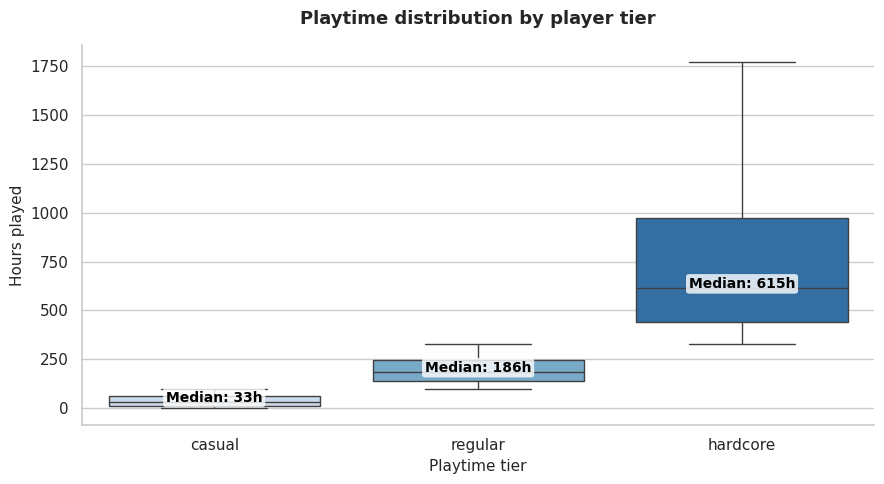

In [11]:
ingested_raw["playtime_tier"] = pd.qcut(
    ingested_raw["hour_played"],
    q=[0, 0.33, 0.66, 1.0],
    labels=["casual", "regular", "hardcore"],
)

display(
    ingested_raw.groupby("playtime_tier", observed=True)["hour_played"]
    .describe().round(1)
)

plt.figure(figsize=(9, 5))
ax = sns.boxplot(
    data=ingested_raw, x="playtime_tier", y="hour_played",
    hue="playtime_tier", legend=False, palette="Blues", showfliers=False,
)

medians = ingested_raw.groupby("playtime_tier", observed=True)["hour_played"].median()
for i, median in enumerate(medians):
    ax.text(
        x=i, y=median, s=f"Median: {median:.0f}h",
        ha="center", size=10, color="black", weight="bold",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", boxstyle="round,pad=0.2"),
    )

plt.title("Playtime distribution by player tier", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Playtime tier", fontsize=11)
plt.ylabel("Hours played", fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

#### Key Takeaways on Playtime Tiers

* **Balanced Class Distribution:** By construction, the quantile-based discretization splits the dataset into three balanced groups of approximately 123,000 reviews each, with cutoffs established at **95 hours** (Casual/Regular boundary) and **327 hours** (Regular/Hardcore boundary).
* **Corpus-Specific Context:** A 95-hour cutoff for a "Casual" tier would be unusually high for single-player narrative titles. However, as established in Notebook 01, this corpus is heavily dominated by multiplayer titles (*PUBG*, *GTA V*, *Rust*, and *Rocket League*), where long-term engagement is standard. These thresholds accurately reflect this specific dataset rather than a general gaming benchmark.
* **Handling Extreme Outliers:** The maximum reported playtime reaches 22,830 hours (~2.6 years of continuous play). These extreme values are preserved: they are plausible for dedicated survival or competitive players, and assigning them to the ordinal `Hardcore` tier naturally bounds their influence without requiring arbitrary data truncation.

## 9.3 Recommendation Rate by Playtime Tier

To ensure that the engineered playtime tiers capture meaningful variance rather than serving as a purely arbitrary feature, we evaluate recommendation rates across each tier.

,Recommended rate,Reviews
playtime_tier,,
casual,62.6,122329
regular,68.6,121260
hardcore,72.0,125325


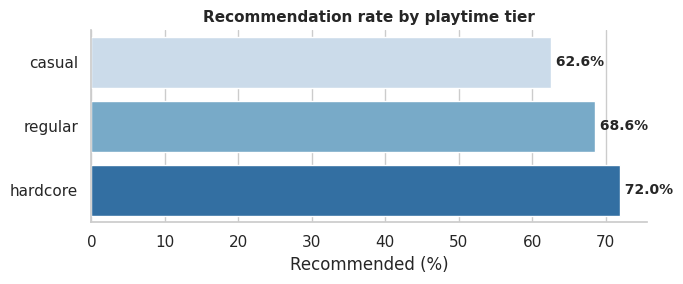

In [12]:
tier_rates = (
    ingested_raw.groupby("playtime_tier", observed=True)["label"]
    .agg(["mean", "size"])
)
tier_rates.columns = ["Recommended rate", "Reviews"]
tier_rates["Recommended rate"] = (tier_rates["Recommended rate"] * 100).round(1)

display(tier_rates)

plt.figure(figsize=(7, 3))
ax = sns.barplot(
    data=tier_rates.reset_index(), x="Recommended rate", y="playtime_tier",
    hue="playtime_tier", legend=False, palette="Blues", orient="h",
)
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f" {width:.1f}%", (width, p.get_y() + p.get_height() / 2.0),
                ha="left", va="center", fontsize=10, fontweight="bold")

plt.title("Recommendation rate by playtime tier", fontsize=11, fontweight="bold")
plt.xlabel("Recommended (%)")
plt.ylabel("")
sns.despine()
plt.tight_layout()
plt.show()

#### Analytical Insights & Modeling Implications

* **Observed Trend:** The recommendation rate increases monotonically with time investment, rising from **62.6%** among casual players to **72.0%** among hardcore players (a net gain of 9.4 percentage points). Players who spend hundreds of hours in a game are naturally more likely to view it favorably overall.
* **Corroborating Statistical Findings:** Notebook 01 measured a rank-biserial effect size of $r = -0.13$ between continuous playtime and recommendation status. Viewing this relationship as categorical rates confirms that while playtime holds a real, measurable signal, the overall correlation remains relatively modest.
* **Downstream Strategy for Notebook 05:** Because playtime alone exhibits a moderate effect size (a 9.4 percentage point spread across extreme tiers), it should not be relied upon as the sole feature for segmenting user feedback. In Notebook 05, per-game topic modeling will cross-reference `playtime_tier` alongside text sentiment and specific feature themes (e.g., technical bugs vs. endgame balancing) rather than analyzing playtime in isolation.

# 10. Export

In [13]:
OUTPUT_PATH = PROCESSED_DIR / "clean_sample.parquet"
ingested_raw.to_parquet(OUTPUT_PATH, index=False)

audit_df = pd.DataFrame(audit_log, columns=["Step", "Rows removed"])
audit_df["Share of raw corpus"] = (audit_df["Rows removed"] / CORPUS_START * 100).round(2)

display(Markdown("### Rows removed, by step"))
display(audit_df)

display(
    Markdown(
        f"Raw corpus: `{CORPUS_START:,}`  \n"
        f"Total removed: `{CORPUS_START - len(ingested_raw):,}` "
        f"({(CORPUS_START - len(ingested_raw)) / CORPUS_START:.2%})  \n"
        f"Exported: `{len(ingested_raw):,}` rows to `{OUTPUT_PATH.name}` "
        f"(`{OUTPUT_PATH.stat().st_size / (1024 * 1024):.2f} MB`)  \n\n"
        f"Columns: `{list(ingested_raw.columns)}`"
    )
)

### Rows removed, by step

,Step,Rows removed,Share of raw corpus
0,Empty review text,1516,0.35
1,Exact row duplicates,0,0.00
2,Coordinated copy-paste,1436,0.33
3,Reviews under 3 words,63025,14.49


Raw corpus: `434,891`  
Total removed: `65,977` (15.17%)  
Exported: `368,914` rows to `clean_sample.parquet` (`146.64 MB`)  

Columns: `['date_posted', 'funny', 'helpful', 'hour_played', 'is_early_access_review', 'recommendation', 'review', 'title', 'word_count', 'received_free', 'review_raw', 'review_clean', 'clean_token_count', 'label', 'has_helpful_votes', 'has_funny_votes', 'playtime_tier']`

The audit table accounts for every row that left the corpus, which matters because the total is not small: the short-review filter alone removes more than a tenth of everything. Reporting it step by step means the loss is a documented decision rather than an unexplained gap between the raw file and the modelling set.

# What this notebook produced, and what comes next

A clean, deduplicated dataset with two standardized text columns and five engineered features. Every filtering rule applied here directly addresses a quality or structural finding established during the Notebook 01 audit.

### Output columns

| Column | Built from | Used by |
|---|---|---|
| `review_raw` | Minimal cleaning (markup stripping, boilerplate removal) | NB03 baseline, NB04 fine-tuning, NB05 embeddings |
| `review_clean` | Lowercased, noise & spam stripped, whitespace normalized | NB04 TF-IDF, NB05 c-TF-IDF keywords |
| `label` | `recommendation` mapped to 0/1 | NB03 and NB04 ground truth target |
| `received_free` | Binary indicator derived from Steam boilerplate notice | Structural diagnostic feature |
| `has_helpful_votes` | Binarised `helpful` votes count | Engagement feature & signal analysis |
| `has_funny_votes` | Binarised `funny` votes count | Engagement feature & signal analysis |
| `playtime_tier` | Quantiles of `hour_played` | NB05 topic segmentation & analysis |
| `clean_token_count` | Length of `review_clean` (word count) | Diagnostic feature for text coverage |

---

### What carries into the next notebooks

* **Target Distribution & Baseline:** The dataset maintains a ~69.8% positive class majority (`label = 1`), establishing our majority-class baseline floor for downstream evaluation in Notebooks 03 and 04.
* **Strict Two-Column Text Pipeline:**
  * Use `review_raw` exclusively for Transformer-based architectures (Notebooks 03, 04, and 05 embeddings) to preserve syntactic integrity and context.
  * Use `review_clean` exclusively for bag-of-words / TF-IDF representations (Notebook 04 TF-IDF, NB05 c-TF-IDF).
  * *Note:* Passing tokenized/stripped text into Transformer models degrades contextual representations silently without throwing errors.
* **Residual Review-Bombing Signal:** While exact duplicates (such as repeated PUBG and GTA V copypastas) have been removed, slight text variants remain. Notebook 05 should monitor for unusually dense or homogeneous clusters during topic extraction.

---

### Open questions carried forward

* **Free-Product Confound:** Reviews flagged with `received_free` show distinct length and sentiment characteristics. Evaluating whether this gap stems from reviewer bias or text brevity requires joint modeling of `received_free` and `clean_token_count` in subsequent analytical notebooks.
* **Per-Game Playtime Granularity:** Global `playtime_tier` quantiles provide a unified baseline, but player engagement varies significantly across genres (e.g., survival vs. short narrative games). Notebook 05 will evaluate whether per-game playtime stratification isolates specific user complaints more effectively.